In [17]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score
from tqdm import tqdm

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load test data
df_test = pd.read_csv("/kaggle/input/nwenew/test_split.csv")
texts = df_test["text"].tolist()
true_labels = df_test["label"].tolist()

# Models to evaluate
models_to_test = {
    "blanchefort/rubert-base-cased-sentiment": {"label_map": {0: 0, 1: 1, 2: 2}},  # pos, neu, neg
    "mxlcw/rubert-tiny2-russian-financial-sentiment": {"label_map": {0: 0, 1: 1, 2: 2}}  # already aligned
}

def predict(model_name, texts):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(device)
    model.eval()

    preds = []
    for text in tqdm(texts, desc=f"Predicting with {model_name}"):
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=512
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            pred_label = torch.argmax(outputs.logits, dim=1).item()
        preds.append(pred_label)
    return preds

# Evaluate each model
for model_name, config in models_to_test.items():
    print(f"\n--- Evaluating: {model_name} ---")
    raw_preds = predict(model_name, texts)
    
    # Map model-specific labels to standard: 0=Neutral, 1=Positive, 2=Negative
    mapped_preds = [config["label_map"].get(p, p) for p in raw_preds]

    # Metrics
    acc = accuracy_score(true_labels, mapped_preds)
    rec = recall_score(true_labels, mapped_preds, average="macro")
    f1_macro = f1_score(true_labels, mapped_preds, average="macro")
    f1_weighted = f1_score(true_labels, mapped_preds, average="weighted")

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Recall: {rec:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")

    # Detailed classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, mapped_preds, target_names=["Neutral", "Positive", "Negative"]))


Using device: cuda

--- Evaluating: blanchefort/rubert-base-cased-sentiment ---


Predicting with blanchefort/rubert-base-cased-sentiment: 100%|██████████| 539/539 [00:18<00:00, 28.38it/s]


Accuracy: 0.3581
Macro Recall: 0.3582
Macro F1: 0.3227
Weighted F1: 0.3293

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.41      0.56      0.48       216
    Positive       0.43      0.12      0.19       203
    Negative       0.25      0.39      0.30       120

    accuracy                           0.36       539
   macro avg       0.36      0.36      0.32       539
weighted avg       0.38      0.36      0.33       539


--- Evaluating: mxlcw/rubert-tiny2-russian-financial-sentiment ---


Predicting with mxlcw/rubert-tiny2-russian-financial-sentiment: 100%|██████████| 539/539 [00:01<00:00, 287.59it/s]

Accuracy: 0.6698
Macro Recall: 0.6583
Macro F1: 0.6560
Weighted F1: 0.6670

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.73      0.60      0.66       216
    Positive       0.66      0.80      0.72       203
    Negative       0.59      0.57      0.58       120

    accuracy                           0.67       539
   macro avg       0.66      0.66      0.66       539
weighted avg       0.67      0.67      0.67       539



**So gonna fine tune rubert-tiny2-russian-financial-sentiment**

In [4]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
import matplotlib.pyplot as plt
import os

MODEL_NAME = 'mxlcw/rubert-tiny2-russian-financial-sentiment'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10
BATCH_SIZE = 16
SAVE_PATH = "./finetuned_checkpoints"
os.makedirs(SAVE_PATH, exist_ok=True)

train_df = pd.read_csv('/kaggle/input/nwenew/train_split.csv')
test_df = pd.read_csv('/kaggle/input/nwenew/test_split.csv')

train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [18]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=512)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_texts, train_labels)
test_dataset = SentimentDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
model.to(DEVICE)

# === TRAINING LOOP ===
optimizer = AdamW(model.parameters(), lr=2e-5) # torch.optim.AdamW(model.parameters(), lr=2e-5)

train_losses = []
test_losses = []
metrics_per_epoch = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # === Evaluation ===
    model.eval()
    total_test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_test_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, average='macro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    print(f"\nEpoch {epoch+1} Results:")
    print(f"Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
    print(f"Accuracy: {acc:.4f}, Macro Recall: {rec:.4f}, F1 Macro: {f1_macro:.4f}, F1 Weighted: {f1_weighted:.4f}")
    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=["Neutral", "Positive", "Negative"]))

    # Save model
    model.save_pretrained(f"{SAVE_PATH}/epoch_{epoch+1}")
    tokenizer.save_pretrained(f"{SAVE_PATH}/epoch_{epoch+1}")

    metrics_per_epoch.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'test_loss': avg_test_loss,
        'accuracy': acc,
        'recall': rec,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    })

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Training Epoch 1: 100%|██████████| 151/151 [00:17<00:00,  8.87it/s]



Epoch 1 Results:
Train Loss: 0.4766, Test Loss: 0.8066
Accuracy: 0.6679, Macro Recall: 0.6742, F1 Macro: 0.6606, F1 Weighted: 0.6689
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.77      0.58      0.66       216
    Positive       0.69      0.74      0.72       203
    Negative       0.54      0.70      0.61       120

    accuracy                           0.67       539
   macro avg       0.66      0.67      0.66       539
weighted avg       0.69      0.67      0.67       539



Training Epoch 2: 100%|██████████| 151/151 [00:16<00:00,  9.19it/s]



Epoch 2 Results:
Train Loss: 0.3767, Test Loss: 0.8416
Accuracy: 0.6679, Macro Recall: 0.6602, F1 Macro: 0.6612, F1 Weighted: 0.6677
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.66      0.70      0.68       216
    Positive       0.70      0.66      0.68       203
    Negative       0.63      0.62      0.62       120

    accuracy                           0.67       539
   macro avg       0.66      0.66      0.66       539
weighted avg       0.67      0.67      0.67       539



Training Epoch 3: 100%|██████████| 151/151 [00:17<00:00,  8.86it/s]


...


Epoch 8 Results:
Train Loss: 0.0667, Test Loss: 1.2680
Accuracy: 0.6642, Macro Recall: 0.6682, F1 Macro: 0.6589, F1 Weighted: 0.6643
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.73      0.60      0.66       216
    Positive       0.67      0.72      0.70       203
    Negative       0.57      0.68      0.62       120

    accuracy                           0.66       539
   macro avg       0.66      0.67      0.66       539
weighted avg       0.67      0.66      0.66       539



Training Epoch 9: 100%|██████████| 151/151 [00:16<00:00,  9.05it/s]



Epoch 9 Results:
Train Loss: 0.0437, Test Loss: 1.3404
Accuracy: 0.6716, Macro Recall: 0.6778, F1 Macro: 0.6662, F1 Weighted: 0.6733
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.76      0.62      0.68       216
    Positive       0.68      0.71      0.70       203
    Negative       0.56      0.71      0.62       120

    accuracy                           0.67       539
   macro avg       0.67      0.68      0.67       539
weighted avg       0.69      0.67      0.67       539



Training Epoch 10: 100%|██████████| 151/151 [00:16<00:00,  9.07it/s]



Epoch 10 Results:
Train Loss: 0.0352, Test Loss: 1.3991
Accuracy: 0.6475, Macro Recall: 0.6478, F1 Macro: 0.6430, F1 Weighted: 0.6481
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.67      0.65      0.66       216
    Positive       0.67      0.65      0.66       203
    Negative       0.58      0.65      0.61       120

    accuracy                           0.65       539
   macro avg       0.64      0.65      0.64       539
weighted avg       0.65      0.65      0.65       539



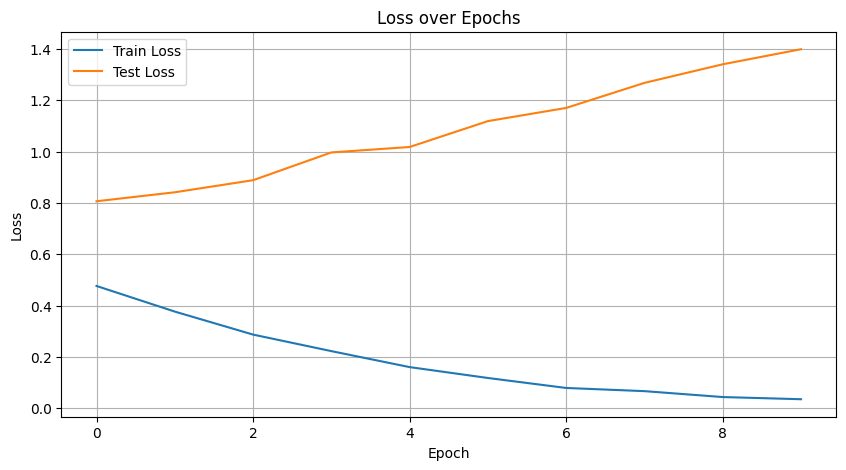


=== Metrics Per Epoch ===
   epoch  train_loss  test_loss  accuracy    recall  f1_macro  f1_weighted
0      1    0.476560   0.806628  0.667904  0.674182  0.660590     0.668896
1      2    0.376724   0.841646  0.667904  0.660156  0.661159     0.667742
2      3    0.287102   0.888720  0.677180  0.675429  0.669500     0.677845
3      4    0.222675   0.996921  0.660482  0.672107  0.657432     0.662195
4      5    0.160368   1.018126  0.682746  0.675515  0.675685     0.681951
5      6    0.117972   1.118986  0.654917  0.658835  0.650947     0.655905
6      7    0.079078   1.170401  0.671614  0.667194  0.664113     0.671333
7      8    0.066689   1.267992  0.664193  0.668231  0.658924     0.664349
8      9    0.043685   1.340437  0.671614  0.677811  0.666223     0.673263
9     10    0.035230   1.399117  0.647495  0.647823  0.642960     0.648146


In [8]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# === PRINT METRICS TABLE ===
metrics_df = pd.DataFrame(metrics_per_epoch)
print("\n=== Metrics Per Epoch ===")
print(metrics_df)

**Now for the other one**

In [19]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AdamW, get_scheduler
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report
from tqdm import tqdm
import torch

MODEL_NAME = "blanchefort/rubert-base-cased-sentiment"
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "./saved_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=2e-5)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=EPOCHS * len(train_loader),
)

train_losses = []
test_losses = []
metrics_per_epoch = []

best_f1 = 0.0
patience = 2
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # === Evaluation ===
    model.eval()
    total_test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_test_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, average='macro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    print(f"\nEpoch {epoch+1} Results:")
    print(f"Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
    print(f"Accuracy: {acc:.4f}, Macro Recall: {rec:.4f}, F1 Macro: {f1_macro:.4f}, F1 Weighted: {f1_weighted:.4f}")
    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=["Neutral", "Positive", "Negative"]))

    # Save model if F1 improved
    if f1_macro > best_f1:
        best_f1 = f1_macro
        patience_counter = 0
        model.save_pretrained(f"{SAVE_PATH}/best_model")
        tokenizer.save_pretrained(f"{SAVE_PATH}/best_model")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    metrics_per_epoch.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'test_loss': avg_test_loss,
        'accuracy': acc,
        'recall': rec,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    })

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Training Epoch 1: 100%|██████████| 151/151 [04:02<00:00,  1.61s/it]



Epoch 1 Results:
Train Loss: 1.1698, Test Loss: 1.1338
Accuracy: 0.3506, Macro Recall: 0.3438, F1 Macro: 0.2952, F1 Weighted: 0.2968
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.32      0.08      0.13       216
    Positive       0.38      0.69      0.49       203
    Negative       0.26      0.26      0.26       120

    accuracy                           0.35       539
   macro avg       0.32      0.34      0.30       539
weighted avg       0.33      0.35      0.30       539



Training Epoch 2: 100%|██████████| 151/151 [04:01<00:00,  1.60s/it]



Epoch 2 Results:
Train Loss: 1.0834, Test Loss: 1.0990
Accuracy: 0.3173, Macro Recall: 0.3648, F1 Macro: 0.3004, F1 Weighted: 0.2883
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.51      0.11      0.18       216
    Positive       0.38      0.35      0.37       203
    Negative       0.25      0.63      0.36       120

    accuracy                           0.32       539
   macro avg       0.38      0.36      0.30       539
weighted avg       0.40      0.32      0.29       539



Training Epoch 3: 100%|██████████| 151/151 [04:01<00:00,  1.60s/it]



Epoch 3 Results:
Train Loss: 1.0554, Test Loss: 1.0784
Accuracy: 0.4082, Macro Recall: 0.3771, F1 Macro: 0.3734, F1 Weighted: 0.3939
Classification Report:
               precision    recall  f1-score   support

     Neutral       0.41      0.59      0.49       216
    Positive       0.43      0.33      0.38       203
    Negative       0.34      0.21      0.26       120

    accuracy                           0.41       539
   macro avg       0.39      0.38      0.37       539
weighted avg       0.40      0.41      0.39       539



Training Epoch 4:  30%|██▉       | 45/151 [01:12<02:51,  1.61s/it]


KeyboardInterrupt: 